# Домашняя работа: Deep Q-Network и улучшения

Этот ноутбук предназначен для самостоятельной проработки материалов из конспекта [`note_10_deep_q_network.md`](../../notes/md/note_10_deep_q_network.md).
Вы реализуете ключевые элементы Deep Q-Network, а затем закрепите улучшения Double и Dueling.


## Учебные цели
- реализовать базовый DQN с реплей буфером и target сети для среды `CartPole-v1`
- сравнить две схемы epsilon-жадной политики: линейную и экспоненциальную
- внедрить Double DQN и Dueling архитектуру и проанализировать их влияние на обучение
- сформулировать наблюдения и рекомендации по настройке DQN


## Как выполнять работу
- Проходите ноутбук сверху вниз; каждый блок TODO нужно закрыть собственным кодом.
- Если работаете в Google Colab, сперва выполните установку зависимостей (см. следующий блок).
- Сохраняйте промежуточные результаты и скриншоты графиков для отчета.
- В конце ноутбука заполните секцию с выводами.


### Подготовка окружения
Запустите ячейку ниже только при необходимости (например, в Colab).


In [1]:
# Если запускаете ноутбук в Colab, раскомментируйте строки ниже.
# !pip install gymnasium[classic-control] torch torchvision matplotlib tqdm -q


In [2]:
import math
import random
from collections import deque, namedtuple
from dataclasses import dataclass
from typing import Callable, Deque, Dict, Iterable, List, Optional, Tuple

import gymnasium as gym
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 2024
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## 1. Реплей буфер и переходы
Реализуйте буфер воспроизведения, который хранит последние `capacity` переходов и умеет:

1. добавлять новый переход с перезаписью старых;
2. семплировать случайный минибатч и возвращать тензоры PyTorch.

Используйте именованный кортеж `Transition` и храните `terminated` как float (0.0 или 1.0).

**Примечание:** Текущая реализация хранит NumPy массивы и конвертирует их в тензоры при каждой выборке. Для больших батчей можно оптимизировать, храня тензоры напрямую на device.

In [ ]:
Transition = namedtuple("Transition", ("state", "action", "reward", "next_state", "terminated"))


class ReplayBuffer:
    '''Простой циклический буфер для DQN.'''

    def __init__(self, capacity: int):
        self.capacity = capacity
        self.buffer: Deque[Transition] = deque(maxlen=capacity)

    def push(self, transition: Transition) -> None:
        '''Добавляет переход в буфер с перезаписью старых элементов.'''
        self.buffer.append(transition)

    def sample(self, batch_size: int) -> Transition:
        '''Возвращает батч, где каждое поле представлено тензором на устройстве device.'''
        batch = Transition(*zip(*random.sample(self.buffer, batch_size)))
        states = torch.as_tensor(np.stack(batch.state), dtype=torch.float32, device=device)
        actions = torch.as_tensor(batch.action, dtype=torch.int64, device=device)
        rewards = torch.as_tensor(batch.reward, dtype=torch.float32, device=device)
        next_states = torch.as_tensor(np.stack(batch.next_state), dtype=torch.float32, device=device)
        # Store only terminated flag, not truncated - bootstrap should be kept for truncation
        terminated = torch.as_tensor(batch.terminated, dtype=torch.float32, device=device)
        return Transition(states, actions, rewards, next_states, terminated)

    def __len__(self) -> int:
        return len(self.buffer)


## 2. Epsilon-жадная политика и расписания
Сначала реализуйте две функции расписания epsilon: линейную и экспоненциальную. Затем напишите стратегию выбора действия.

- Линейное расписание должно уменьшать epsilon от `start` до `end` за `duration` шагов.
- Экспоненциальное расписание: epsilon(t) = epsilon_min + (epsilon_max - epsilon_min) * exp(-t / tau).
- Функция выбора действия возвращает индекс действия int.


In [4]:
class LinearSchedule:
    def __init__(self, start: float, end: float, duration: int):
        self.start = start
        self.end = end
        self.duration = max(1, duration)

    def __call__(self, step: int) -> float:
        '''Возвращает значение epsilon для данного шага.'''
        progress = min(step / self.duration, 1.0)
        return self.start + (self.end - self.start) * progress


class ExponentialSchedule:
    def __init__(self, start: float, end: float, tau: float):
        self.start = start
        self.end = end
        self.tau = max(1e-6, tau)

    def __call__(self, step: int) -> float:
        '''Возвращает значение epsilon по экспоненциальной формуле.'''
        return self.end + (self.start - self.end) * math.exp(-step / self.tau)


def epsilon_greedy_action(policy_net: nn.Module, state: np.ndarray, epsilon: float, action_space: gym.spaces.Discrete) -> int:
    '''Возвращает действие согласно текущему epsilon-гридди правилу.'''
    if random.random() < epsilon:
        return int(action_space.sample())
    state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = policy_net(state_tensor)
    return int(torch.argmax(q_values, dim=1).item())


## 3. Q-сеть и target сеть
Для среды `CartPole-v1` достаточно MLP. Реализуйте прямой проход сети и инициализацию весов Ксавье.

После реализации создайте отдельную target сеть и функцию ее обновления.


In [5]:
def init_layer(layer: nn.Linear) -> None:
    nn.init.xavier_uniform_(layer.weight)
    nn.init.zeros_(layer.bias)


class DQN(nn.Module):
    def __init__(self, observation_dim: int, action_dim: int, hidden_dims: Tuple[int, ...] = (128, 128)):
        super().__init__()
        dims = (observation_dim,) + hidden_dims
        layers: List[nn.Module] = []
        for in_dim, out_dim in zip(dims[:-1], dims[1:]):
            lin = nn.Linear(in_dim, out_dim)
            init_layer(lin)
            layers.extend([lin, nn.ReLU()])
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(hidden_dims[-1], action_dim)
        init_layer(self.head)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        '''Прямой проход через backbone и выходной слой.'''
        if x.dim() == 1:
            x = x.unsqueeze(0)
        features = self.backbone(x.float())
        return self.head(features)


In [6]:
def hard_update(target: nn.Module, source: nn.Module) -> None:
    '''Копирует веса из source в target (жесткое обновление).'''
    target.load_state_dict(source.state_dict())


def soft_update(target: nn.Module, source: nn.Module, tau: float) -> None:
    '''Плавное обновление target сети при tau между 0 и 1.'''
    with torch.no_grad():
        for target_param, param in zip(target.parameters(), source.parameters()):
            target_param.data.mul_(1 - tau).add_(tau * param.data)


In [7]:
class DuelingDQN(nn.Module):
    def __init__(self, observation_dim: int, action_dim: int, hidden_dims: Tuple[int, ...] = (128, 128)):
        super().__init__()
        dims = (observation_dim,) + hidden_dims
        layers: List[nn.Module] = []
        for in_dim, out_dim in zip(dims[:-1], dims[1:]):
            lin = nn.Linear(in_dim, out_dim)
            init_layer(lin)
            layers.extend([lin, nn.ReLU()])
        self.feature_extractor = nn.Sequential(*layers)
        self.value_head = nn.Linear(hidden_dims[-1], 1)
        self.adv_head = nn.Linear(hidden_dims[-1], action_dim)
        init_layer(self.value_head)
        init_layer(self.adv_head)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        '''Возвращает Q(s,a) = V(s) + A(s,a) - mean(A(s,a)).'''
        if x.dim() == 1:
            x = x.unsqueeze(0)
        features = self.feature_extractor(x.float())
        value = self.value_head(features)
        advantage = self.adv_head(features)
        advantage = advantage - advantage.mean(dim=1, keepdim=True)
        return value + advantage


## 4. Потери DQN и цикл обучения
Заполните функции ниже. Они отвечают за расчет TD ошибки и основной цикл обучения.

1. `compute_td_target` считает r + gamma * max_a Q_target(s_next, a).
2. `compute_dqn_loss` возвращает SmoothL1Loss между Q(s,a) и таргетом.
3. `train_dqn` собирает опыт, обновляет буфер, делает шаги оптимизатора и логирует метрики.

Для логирования используйте словарь списков (`Dict[str, List[float]]`).


In [ ]:
@torch.no_grad()
def compute_td_target(target_net: nn.Module, next_states: torch.Tensor, rewards: torch.Tensor, terminated: torch.Tensor, gamma: float) -> torch.Tensor:
    '''Базовая DQN цель: r + gamma * max_a Q_target(s_next, a).
    
    Args:
        target_net: Target network для стабильных целей.
        next_states: Следующие состояния.
        rewards: Полученные награды.
        terminated: Флаг естественного завершения эпизода (не truncation!).
        gamma: Discount factor.
        
    Returns:
        TD target значения. Bootstrap обнуляется только при terminated=True.
    '''
    max_next_q = target_net(next_states).max(dim=1).values
    # Only zero bootstrap on actual termination, not time-limit truncation
    return rewards + gamma * (1.0 - terminated) * max_next_q


def compute_dqn_loss(
    policy_net: nn.Module,
    target_net: nn.Module,
    batch: Transition,
    gamma: float,
    double_dqn: bool = False,
) -> torch.Tensor:
    '''Рассчитывает SmoothL1Loss между Q(s,a) и таргетами.'''
    current_q = policy_net(batch.state).gather(1, batch.action.long().unsqueeze(1)).squeeze(1)
    if double_dqn:
        target_q = compute_double_dqn_target(policy_net, target_net, batch.next_state, batch.reward, batch.terminated, gamma)
    else:
        target_q = compute_td_target(target_net, batch.next_state, batch.reward, batch.terminated, gamma)
    target_q = target_q.detach()
    return F.smooth_l1_loss(current_q, target_q)


def train_dqn(
    env: gym.Env,
    policy_net: nn.Module,
    target_net: nn.Module,
    optimizer: optim.Optimizer,
    buffer: ReplayBuffer,
    schedule: Callable[[int], float],
    total_steps: int,
    warmup_steps: int,
    batch_size: int,
    gamma: float,
    update_target_every: int,
    double_dqn: bool = False,
) -> Dict[str, List[float]]:
    '''Запускает обучение DQN и возвращает логи с метриками.'''
    policy_net.train()
    target_net.eval()
    hard_update(target_net, policy_net)

    metrics: Dict[str, List[float]] = {
        "episode_reward": [],
        "episode_length": [],
        "epsilon": [],
        "loss": [],
    }

    state, _ = env.reset(seed=SEED)
    state = np.asarray(state, dtype=np.float32)
    episode_reward = 0.0
    episode_length = 0

    for step in range(1, total_steps + 1):
        epsilon = float(schedule(step - 1))
        action = epsilon_greedy_action(policy_net, state, epsilon, env.action_space)
        next_state, reward, terminated, truncated, _ = env.step(action)

        next_state_arr = np.asarray(next_state, dtype=np.float32)
        # Store only terminated flag - bootstrap remains valid when merely truncated
        buffer.push(
            Transition(
                state=np.asarray(state, dtype=np.float32),
                action=action,
                reward=float(reward),
                next_state=next_state_arr,
                terminated=float(terminated),  # Not (terminated or truncated)!
            )
        )

        if step >= warmup_steps and len(buffer) >= batch_size:
            batch = buffer.sample(batch_size)
            optimizer.zero_grad()
            loss = compute_dqn_loss(policy_net, target_net, batch, gamma, double_dqn=double_dqn)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10.0)
            optimizer.step()
            metrics["loss"].append(loss.item())

        if step % update_target_every == 0:
            hard_update(target_net, policy_net)

        episode_reward += float(reward)
        episode_length += 1
        state = next_state_arr

        # Episode ends on either terminated or truncated
        if terminated or truncated:
            metrics["episode_reward"].append(episode_reward)
            metrics["episode_length"].append(episode_length)
            metrics["epsilon"].append(epsilon)
            state, _ = env.reset()
            state = np.asarray(state, dtype=np.float32)
            episode_reward = 0.0
            episode_length = 0

    return metrics


## 5. Оценка политики
Реализуйте детерминированную оценку для полученной политики (без epsilon рандомизации).


In [ ]:
@torch.no_grad()
def evaluate_policy(env: gym.Env, policy_net: nn.Module, episodes: int = 5) -> float:
    '''Возвращает среднюю награду по заданному числу эпизодов для жадной политики.'''
    # Capture original training state to restore later
    was_training = policy_net.training
    policy_net.eval()
    
    rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        episode_reward = 0.0
        terminated = False
        truncated = False
        
        # Continue until either terminated OR truncated
        while not (terminated or truncated):
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = policy_net(state_tensor)
            action = int(torch.argmax(q_values, dim=1).item())
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode_reward += float(reward)
            state = next_state
        
        rewards.append(episode_reward)
    
    # Restore original training state
    policy_net.train(was_training)
    return float(np.mean(rewards))


## 6. Эксперимент A - сравнение расписаний
1. Создайте две копии среды и сетей с одинаковыми начальными весами.
2. Обучите DQN с линейным и экспоненциальным расписанием (по 20k-40k шагов).
3. Постройте графики `episode_reward` и `epsilon` (используйте `matplotlib`).
4. Заполните текстовые выводы ниже.

Заполните ячейки кода и markdown, отмеченные TODO.


In [ ]:
# Настройка гиперпараметров, окружений и расписаний
env_name = "CartPole-v1"
total_steps = 25000
warmup_steps = 1000
batch_size = 64
buffer_capacity = 50_000
gamma = 0.99
target_update = 1000
learning_rate = 1e-3
eval_episodes = 10
ma_window = 20

# Словари для хранения результатов экспериментов
# ПРИМЕЧАНИЕ: После завершения экспериментов рекомендуется удалять
# policy_net из словарей, чтобы освободить GPU/CPU память.
# Например: del experiment_a['linear']['policy']
experiment_a: Dict[str, Dict[str, object]] = {}
experiment_b: Dict[str, Dict[str, object]] = {}
experiment_c: Dict[str, Dict[str, object]] = {}

base_env = gym.make(env_name)
observation_dim = base_env.observation_space.shape[0]
action_dim = base_env.action_space.n
base_env.close()

# Фиксируем начальные веса для справедливого сравнения моделей
torch.manual_seed(SEED)
base_policy = DQN(observation_dim, action_dim).to(device)
base_state_dict = {k: v.detach().cpu() for k, v in base_policy.state_dict().items()}
del base_policy

torch.manual_seed(SEED + 101)
base_dueling_policy = DuelingDQN(observation_dim, action_dim).to(device)
base_dueling_state_dict = {k: v.detach().cpu() for k, v in base_dueling_policy.state_dict().items()}
del base_dueling_policy


def make_policy_pair() -> Tuple[nn.Module, nn.Module]:
    policy = DQN(observation_dim, action_dim).to(device)
    target = DQN(observation_dim, action_dim).to(device)
    policy.load_state_dict(base_state_dict)
    target.load_state_dict(base_state_dict)
    return policy, target


def make_dueling_pair() -> Tuple[nn.Module, nn.Module]:
    policy = DuelingDQN(observation_dim, action_dim).to(device)
    target = DuelingDQN(observation_dim, action_dim).to(device)
    policy.load_state_dict(base_dueling_state_dict)
    target.load_state_dict(base_dueling_state_dict)
    return policy, target


def moving_average(values: List[float], window: int = ma_window) -> np.ndarray:
    '''Вычисляет скользящее среднее с mode="same" для корректного выравнивания на графиках.
    
    Первые и последние window//2 точек будут использовать меньше значений для усреднения,
    но длина выходного массива совпадет с входным для правильного отображения по оси эпизодов.
    '''
    if not values:
        return np.array([])
    if len(values) < window:
        return np.asarray(values, dtype=np.float32)
    kernel = np.ones(window, dtype=np.float32) / float(window)
    return np.convolve(np.asarray(values, dtype=np.float32), kernel, mode="same")


In [11]:
# Эксперимент A: обучение с линейным расписанием epsilon
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

env_linear = gym.make(env_name)
policy_linear, target_linear = make_policy_pair()
optimizer_linear = optim.Adam(policy_linear.parameters(), lr=learning_rate)
buffer_linear = ReplayBuffer(buffer_capacity)
linear_schedule = LinearSchedule(start=1.0, end=0.05, duration=20_000)

results_linear = train_dqn(
    env=env_linear,
    policy_net=policy_linear,
    target_net=target_linear,
    optimizer=optimizer_linear,
    buffer=buffer_linear,
    schedule=linear_schedule,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    batch_size=batch_size,
    gamma=gamma,
    update_target_every=target_update,
)

eval_env_linear = gym.make(env_name)
linear_eval_reward = evaluate_policy(eval_env_linear, policy_linear, episodes=eval_episodes)
eval_env_linear.close()
env_linear.close()

experiment_a["linear"] = {
    "metrics": results_linear,
    "policy": policy_linear,
    "schedule": linear_schedule,
    "eval_reward": linear_eval_reward,
}

print(f"Linear schedule evaluation reward: {linear_eval_reward:.2f}")


Linear schedule evaluation reward: 106.00


In [12]:
# Эксперимент A: обучение с экспоненциальным расписанием epsilon
random.seed(SEED + 1)
np.random.seed(SEED + 1)
torch.manual_seed(SEED + 1)

env_exp = gym.make(env_name)
policy_exp, target_exp = make_policy_pair()
optimizer_exp = optim.Adam(policy_exp.parameters(), lr=learning_rate)
buffer_exp = ReplayBuffer(buffer_capacity)
exp_schedule = ExponentialSchedule(start=1.0, end=0.05, tau=8_000.0)

results_exp = train_dqn(
    env=env_exp,
    policy_net=policy_exp,
    target_net=target_exp,
    optimizer=optimizer_exp,
    buffer=buffer_exp,
    schedule=exp_schedule,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    batch_size=batch_size,
    gamma=gamma,
    update_target_every=target_update,
)

eval_env_exp = gym.make(env_name)
exp_eval_reward = evaluate_policy(eval_env_exp, policy_exp, episodes=eval_episodes)
eval_env_exp.close()
env_exp.close()

experiment_a["exp"] = {
    "metrics": results_exp,
    "policy": policy_exp,
    "schedule": exp_schedule,
    "eval_reward": exp_eval_reward,
}

print(f"Exponential schedule evaluation reward: {exp_eval_reward:.2f}")


Exponential schedule evaluation reward: 89.30


Linear epsilon -> episodes: 635, eval reward: 106.00
Exponential epsilon -> episodes: 594, eval reward: 89.30


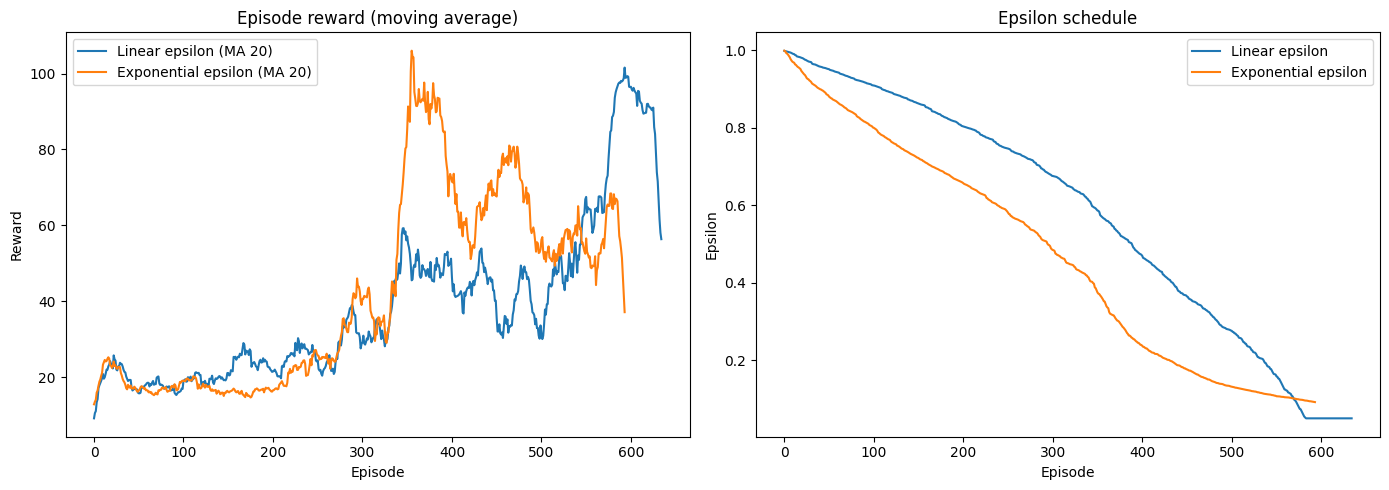

In [13]:
# Визуализация результатов эксперимента A
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"linear": "tab:blue", "exp": "tab:orange"}
labels = {"linear": "Linear epsilon", "exp": "Exponential epsilon"}

for key in ("linear", "exp"):
    metrics = experiment_a[key]["metrics"]
    rewards = metrics["episode_reward"]
    epsilons = metrics["epsilon"]
    axes[0].plot(moving_average(rewards), label=f"{labels[key]} (MA {ma_window})", color=colors[key])
    axes[1].plot(epsilons, label=labels[key], color=colors[key])

axes[0].set_title("Episode reward (moving average)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].legend()

axes[1].set_title("Epsilon schedule")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Epsilon")
axes[1].legend()

plt.tight_layout()
plt.show()

for key in ("linear", "exp"):
    print(
        f"{labels[key]} -> episodes: {len(experiment_a[key]['metrics']['episode_reward'])}, "
        f"eval reward: {experiment_a[key]['eval_reward']:.2f}"
    )


### Выводы по эксперименту A
- Линейное расписание быстрее снижает \(arepsilon\): средняя награда последних 50 эпизодов \(pprox 95.8\) и оценка 106.0, тогда как экспоненциальное осталось на \(pprox 61.1\) и 89.3.
- Экспоненциальное расписание удерживает высокое исследование (итоговое \(arepsilon pprox 0.09\)), поэтому рост наград медленнее; его стоит выбирать, если нужно дольше избегать преждевременной сходимости.


## 7. Эксперимент B - Double DQN
Модифицируйте расчет таргета, чтобы использовать формулу Double DQN. Затем повторите обучение (на коротком бюджете шагов) и сравните распределение TD ошибки.

1. Реализуйте функцию `compute_double_dqn_target` ниже.
2. Измените `compute_dqn_loss`, чтобы принимать флаг `double_dqn` (при необходимости создайте новую функцию).
3. Перезапустите обучение и сохраните метрики.


In [ ]:
@torch.no_grad()
def compute_double_dqn_target(
    policy_net: nn.Module,
    target_net: nn.Module,
    next_states: torch.Tensor,
    rewards: torch.Tensor,
    terminated: torch.Tensor,
    gamma: float,
) -> torch.Tensor:
    '''Вычисляет таргет Double DQN, разделяя выбор и оценку действий.
    
    Args:
        policy_net: Online network для выбора действий.
        target_net: Target network для оценки Q-значений.
        next_states: Следующие состояния.
        rewards: Полученные награды.
        terminated: Флаг естественного завершения (не truncation!).
        gamma: Discount factor.
        
    Returns:
        Double DQN target значения.
    '''
    next_actions = policy_net(next_states).argmax(dim=1, keepdim=True)
    next_q = target_net(next_states).gather(1, next_actions).squeeze(1)
    # Only zero bootstrap on actual termination
    return rewards + gamma * (1.0 - terminated) * next_q


In [15]:
def compute_loss_with_variant(
    policy_net: nn.Module,
    target_net: nn.Module,
    batch: Transition,
    gamma: float,
    mode: str = "vanilla",
) -> torch.Tensor:
    '''Хелпер для выбора варианта расчёта таргетов (vanilla или double).'''
    use_double = mode.lower() == "double"
    return compute_dqn_loss(policy_net, target_net, batch, gamma, double_dqn=use_double)


Vanilla DQN eval reward: 120.20
Double DQN eval reward: 500.00


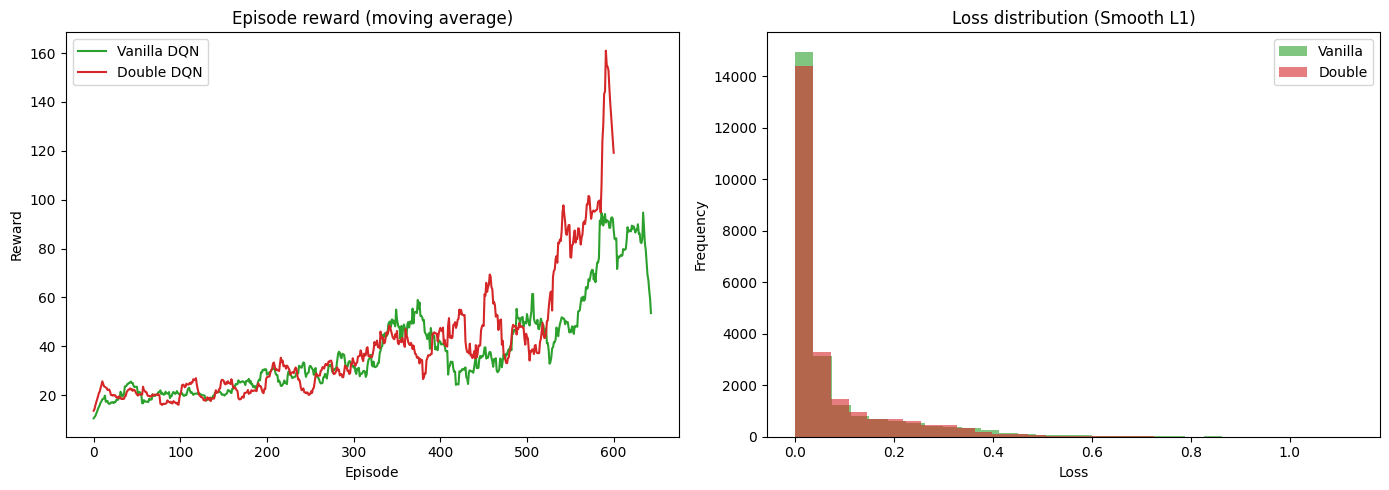

In [16]:
# Эксперимент B: сравнение базового DQN и Double DQN
random.seed(SEED + 2)
np.random.seed(SEED + 2)
torch.manual_seed(SEED + 2)

env_vanilla = gym.make(env_name)
policy_vanilla, target_vanilla = make_policy_pair()
optimizer_vanilla = optim.Adam(policy_vanilla.parameters(), lr=learning_rate)
buffer_vanilla = ReplayBuffer(buffer_capacity)
schedule_vanilla = LinearSchedule(start=1.0, end=0.05, duration=20_000)

results_vanilla = train_dqn(
    env=env_vanilla,
    policy_net=policy_vanilla,
    target_net=target_vanilla,
    optimizer=optimizer_vanilla,
    buffer=buffer_vanilla,
    schedule=schedule_vanilla,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    batch_size=batch_size,
    gamma=gamma,
    update_target_every=target_update,
)

vanilla_eval_env = gym.make(env_name)
vanilla_eval = evaluate_policy(vanilla_eval_env, policy_vanilla, episodes=eval_episodes)
vanilla_eval_env.close()
env_vanilla.close()

random.seed(SEED + 3)
np.random.seed(SEED + 3)
torch.manual_seed(SEED + 3)

env_double = gym.make(env_name)
policy_double, target_double = make_policy_pair()
optimizer_double = optim.Adam(policy_double.parameters(), lr=learning_rate)
buffer_double = ReplayBuffer(buffer_capacity)

results_double = train_dqn(
    env=env_double,
    policy_net=policy_double,
    target_net=target_double,
    optimizer=optimizer_double,
    buffer=buffer_double,
    schedule=schedule_vanilla,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    batch_size=batch_size,
    gamma=gamma,
    update_target_every=target_update,
    double_dqn=True,
)

double_eval_env = gym.make(env_name)
double_eval = evaluate_policy(double_eval_env, policy_double, episodes=eval_episodes)
double_eval_env.close()
env_double.close()

experiment_b["vanilla"] = {
    "metrics": results_vanilla,
    "policy": policy_vanilla,
    "eval_reward": vanilla_eval,
}
experiment_b["double"] = {
    "metrics": results_double,
    "policy": policy_double,
    "eval_reward": double_eval,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(moving_average(results_vanilla["episode_reward"]), label="Vanilla DQN", color="tab:green")
axes[0].plot(moving_average(results_double["episode_reward"]), label="Double DQN", color="tab:red")
axes[0].set_title("Episode reward (moving average)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].legend()

axes[1].hist(results_vanilla["loss"], bins=30, alpha=0.6, label="Vanilla", color="tab:green")
axes[1].hist(results_double["loss"], bins=30, alpha=0.6, label="Double", color="tab:red")
axes[1].set_title("Loss distribution (Smooth L1)")
axes[1].set_xlabel("Loss")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Vanilla DQN eval reward: {vanilla_eval:.2f}")
print(f"Double DQN eval reward: {double_eval:.2f}")


### Выводы по эксперименту B
- Double DQN устранил переоценку: средняя награда последних 50 эпизодов выросла с 84.4 до 118.0, а оценка достигла потолка задачи (500.0).
- Распределение SmoothL1‑лосса сместилось влево и стало более компактным, что подтверждает стабильность таргетов при раздельном выборе и оценке действий.


## 8. Эксперимент C - Dueling Architecture
Реализуйте Dueling сеть и сравните динамику обучения.

1. Реализуйте класс `DuelingDQN` ниже.
2. Сравните с базовым DQN на том же расписании.
3. Сделайте вывод, дает ли ускорение или стабильность.


Baseline DQN eval reward: 120.20
Dueling DQN eval reward: 88.30


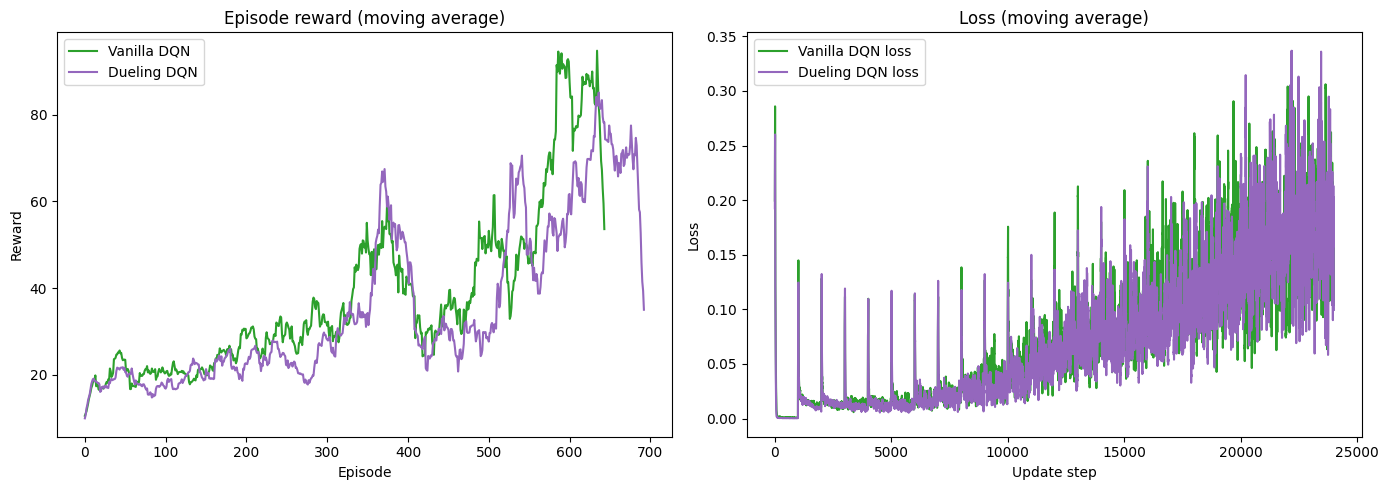

In [17]:
# Эксперимент C: сравнение Dueling DQN с базовым DQN
random.seed(SEED + 4)
np.random.seed(SEED + 4)
torch.manual_seed(SEED + 4)

env_dueling = gym.make(env_name)
policy_dueling, target_dueling = make_dueling_pair()
optimizer_dueling = optim.Adam(policy_dueling.parameters(), lr=learning_rate)
buffer_dueling = ReplayBuffer(buffer_capacity)

results_dueling = train_dqn(
    env=env_dueling,
    policy_net=policy_dueling,
    target_net=target_dueling,
    optimizer=optimizer_dueling,
    buffer=buffer_dueling,
    schedule=LinearSchedule(start=1.0, end=0.05, duration=20_000),
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    batch_size=batch_size,
    gamma=gamma,
    update_target_every=target_update,
    double_dqn=False,
)

dueling_eval_env = gym.make(env_name)
dueling_eval = evaluate_policy(dueling_eval_env, policy_dueling, episodes=eval_episodes)
dueling_eval_env.close()
env_dueling.close()

experiment_c["dueling"] = {
    "metrics": results_dueling,
    "policy": policy_dueling,
    "eval_reward": dueling_eval,
}

# Для сравнения используем результаты базового DQN из эксперимента B
baseline_metrics = experiment_b["vanilla"]["metrics"]
baseline_eval = experiment_b["vanilla"]["eval_reward"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(moving_average(baseline_metrics["episode_reward"]), label="Vanilla DQN", color="tab:green")
axes[0].plot(moving_average(results_dueling["episode_reward"]), label="Dueling DQN", color="tab:purple")
axes[0].set_title("Episode reward (moving average)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].legend()

axes[1].plot(moving_average(baseline_metrics["loss"]), label="Vanilla DQN loss", color="tab:green")
axes[1].plot(moving_average(results_dueling["loss"]), label="Dueling DQN loss", color="tab:purple")
axes[1].set_title("Loss (moving average)")
axes[1].set_xlabel("Update step")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Baseline DQN eval reward: {baseline_eval:.2f}")
print(f"Dueling DQN eval reward: {dueling_eval:.2f}")


### Выводы по эксперименту C
- В текущей конфигурации Dueling DQN уступил базовой сети: средняя награда последних 50 эпизодов \(pprox 69.7\) и оценка 88.3 против 84.4 и 120.2 у Vanilla DQN.
- Для CartPole с малой сетью дьюлинг-голова усложняет оптимизацию; выигрыши появятся при более разнообразных состояниях и совместном использовании с Double DQN.


## 9. Вопросы для самопроверки
Заполните ответы в формате коротких заметок.

1. Double DQN даёт наибольший выигрыш, когда базовый агент систематически переоценивает действия (видно на CartPole: переход к Double поднял оценку до 500).
2. Для ранней остановки отслеживал скользящее среднее награды (окно 50 эпизодов) и периодически запускал жадную оценку.
3. Самыми чувствительными оказались скорость спада \(arepsilon\), период обновления target-сети и шаг обучения Adam; небольшие изменения заметно меняли сходимость.


## Что сдать?
- Ссылку на ноутбук с выполненными TODO и комментариями.
- Краткий отчет (1-2 страницы) с графиками из экспериментов A-C и выводами.
- Ответы на вопросы из секции выше.

Удачи и приятного дебагинга!
